In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('CarPrice_Assignment.csv')
print(data.head())
print(data.info())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data=data.drop(['CarName','car_ID'],axis=1)
data=pd.get_dummies(data,drop_first=True)

In [4]:
X=data.drop('price',axis=1)
y=data['price']

In [10]:
scaler = StandardScaler()
X=scaler.fit_transform(X)
y=scaler.fit_transform(np.array(y).reshape(-1,1))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)
sgd_model.fit(X_train,y_train)
y_pred=sgd_model.predict(X_test)


C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
print('Name: VIJAYAPRATHISHA J')
print('Reg No:212225240184')
print(f"{'MSE':}:{mean_squared_error(y_test,y_pred):}")
print(f"{'MAE':}:{mean_absolute_error(y_test,y_pred):}")
print(f"{'R-squared':}:{r2_score(y_test,y_pred):}")

Name: VIJAYAPRATHISHA J
Reg No:212225240184
MSE:0.21089105193051005
MAE:0.3180119548502328
R-squared:0.8303382258866883


In [12]:
print("\nModel Coefficients:")
print("Coefficient:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coefficients:
Coefficient: [ 3.76200662e-02  1.10983312e-01  9.03519158e-03  1.75843738e-01
  1.80239189e-02  1.79576250e-01  3.01480275e-01 -2.31176109e-02
 -8.70854164e-02 -4.16536551e-04  1.05852437e-01  3.91407270e-02
 -3.88971193e-02 -4.68316428e-02 -1.95174711e-02  2.44021730e-02
  1.64302902e-02 -2.36058701e-02 -9.33002263e-02 -2.01378467e-02
 -9.69696363e-02 -3.30407484e-02  6.23206548e-02  2.14184506e-01
  1.42596545e-02 -9.99108864e-02  7.68930344e-02 -1.50096830e-02
  1.75066011e-04  1.12716327e-02 -3.89247419e-02 -1.52476200e-01
 -8.05915099e-02  7.14548857e-04 -2.83577859e-02  1.12716327e-02
 -5.36985823e-03 -1.58851338e-02  1.95174711e-02 -1.90869839e-02
 -3.32301106e-02 -4.23088540e-02 -1.72178084e-02]
Intercept: [-0.01021128]


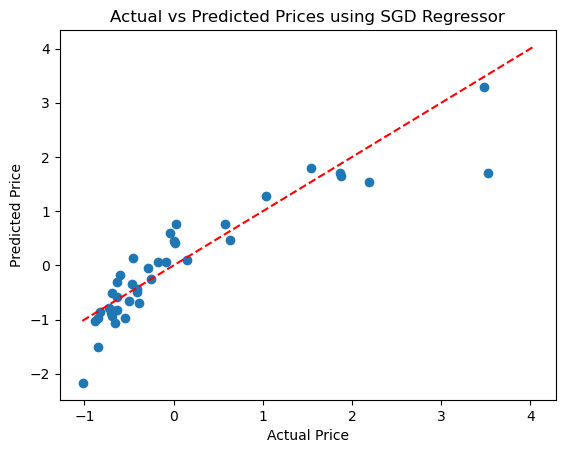

In [13]:
plt.scatter(y_test,y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()